  Loading Models
  [Stage 1] YOLOv8 Detector
            Loading: D:\Fine Tuning\outputs\Final\weights\best.pt
            ✅ Loaded (GPU)

  [Stage 2] CustomCNN Classifier
            Loading: D:\Leaf dataset 2\outputs\CustomCNN\CustomCNN_best.keras
            ✅ Loaded (CPU)

  ✅ Both Models Ready!

────────────────────────────────────────────────────────────
  Processing: WhatsApp Image 2026-03-09 at 1.13.40 AM.jpeg
────────────────────────────────────────────────────────────
  ✅ 5 leaf region(s) detected

  Region 1:
    Disease: Tomato — Septoria_leaf_spot [FILTERED]
    Coarse:  Tomato Early blight leaf
    Conf:    det=64.1%, cls=9.4%

  Region 2:
    Disease: Tomato — Late_blight
    Coarse:  Tomato leaf
    Conf:    det=63.5%, cls=87.3%

  Region 3:
    Disease: Tomato — Late_blight [FILTERED]
    Coarse:  Tomato leaf bacterial spot
    Conf:    det=44.7%, cls=40.8%

  Region 4:
    Disease: Tomato — Late_blight
    Coarse:  Tomato mold leaf
    Conf:    det=44.2%, cls=88.4%

 

C:\Users\LOQ\AppData\Local\Temp\ipykernel_16772\1721940121.py:263: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LOQ\AppData\Local\Temp\ipykernel_16772\1721940121.py:269: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
C:\Users\LOQ\AppData\Local\Temp\ipykernel_16772\1721940121.py:269: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')


  💾 Saved: D:\Fine Tuning\results\result_WhatsApp Image 2026-03-09 at 1.13.40 AM.jpeg


d:\Anaconda\envs\tf_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


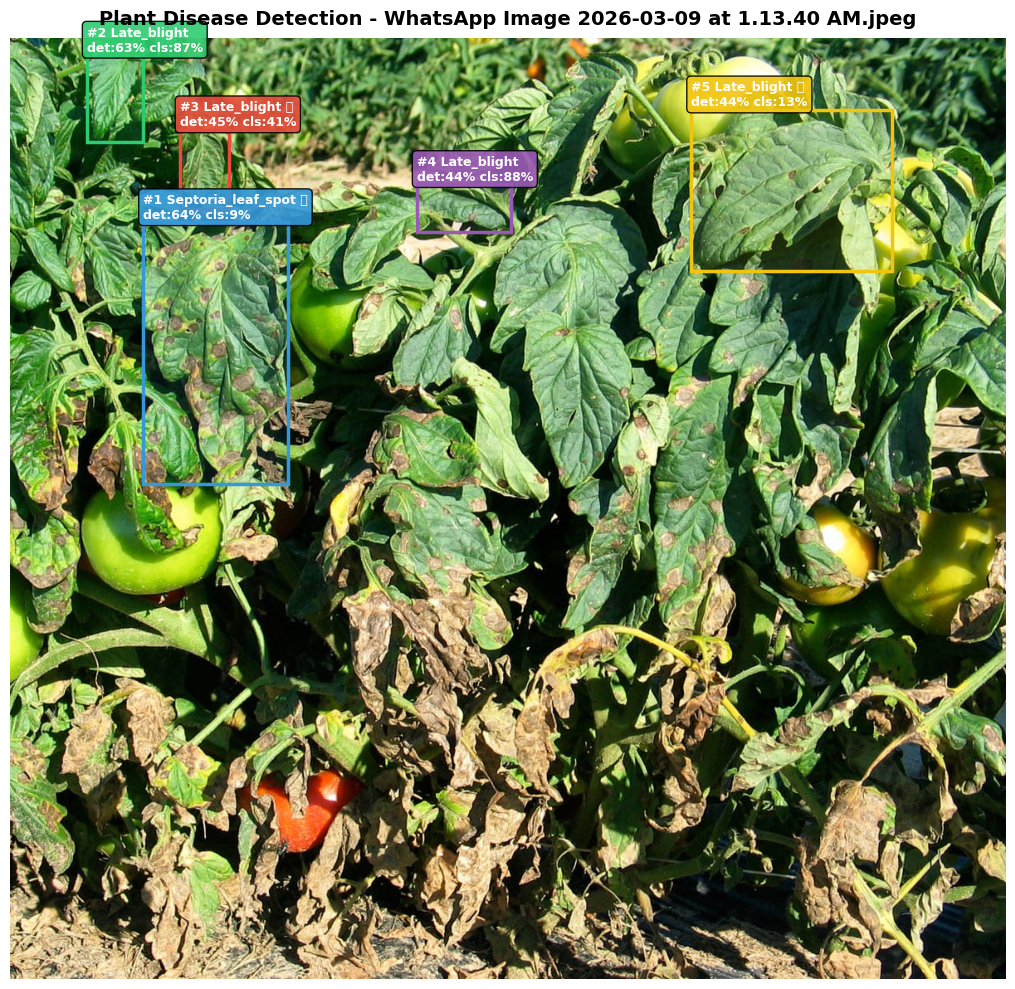


  Inference Complete!


In [1]:
"""
Plant Disease Detection - 2-Stage Inference Script
Stage 1: YOLOv8m (PlantDoc) - Leaf Detection + Coarse Species
Stage 2: CustomCNN (TF) - Disease Classification with Species Filter
"""

import os
import sys
import glob
import numpy as np
import cv2
import tensorflow as tf
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION - Update these paths
# ═══════════════════════════════════════════════════════════════════════════════

# Path to your fine-tuned YOLOv8 weights (best.pt)
YOLO_WEIGHTS = r'D:\Fine Tuning\outputs\train\weights\best.pt'

# Path to your CustomCNN classifier
CLASSIFIER_PATH = r'D:\Leaf dataset 2\outputs\CustomCNN\CustomCNN_best.keras'

# Test image path
TEST_IMAGE = r"C:\Users\LOQ\Downloads\WhatsApp Image 2026-03-09 at 1.13.40 AM.jpeg"

# Confidence threshold for detection
CONF_THRESHOLD = 0.40

# Output directory for results (optional)
OUTPUT_DIR = r'D:\Fine Tuning\results'

# ═══════════════════════════════════════════════════════════════════════════════
# CLASS DEFINITIONS
# ═══════════════════════════════════════════════════════════════════════════════

PLANTDOC_CLASSES = {
    0: 'Cherry leaf', 1: 'Peach leaf',
    2: 'Corn leaf blight', 3: 'Apple rust leaf',
    4: 'Potato leaf late blight', 5: 'Strawberry leaf',
    6: 'Corn rust leaf', 7: 'Tomato leaf late blight',
    8: 'Tomato mold leaf', 9: 'Potato leaf early blight',
    10: 'Apple leaf', 11: 'Tomato leaf yellow virus',
    12: 'Blueberry leaf', 13: 'Tomato leaf mosaic virus',
    14: 'Raspberry leaf', 15: 'Tomato leaf bacterial spot',
    16: 'Squash Powdery mildew leaf', 17: 'grape leaf',
    18: 'Corn Gray leaf spot', 19: 'Tomato Early blight leaf',
    20: 'Apple Scab Leaf', 21: 'Tomato Septoria leaf spot',
    22: 'Tomato leaf', 23: 'Soyabean leaf',
    24: 'Bell_pepper leaf spot', 25: 'Bell_pepper leaf',
    26: 'grape leaf black rot', 27: 'Potato leaf',
    28: 'Tomato two spotted spider mites leaf',
}

CLASSIFIER_CLASSES = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
    'Blueberry___healthy',
    'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy',
    'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot', 'Peach___healthy',
    'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
    'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch', 'Strawberry___healthy',
    'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight',
    'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy'
]

SPECIES_FILTER = {
    'Apple Scab Leaf': 'Apple', 'Apple leaf': 'Apple', 'Apple rust leaf': 'Apple',
    'Tomato leaf': 'Tomato', 'Tomato leaf late blight': 'Tomato',
    'Tomato leaf bacterial spot': 'Tomato', 'Tomato Early blight leaf': 'Tomato',
    'Tomato Septoria leaf spot': 'Tomato', 'Tomato mold leaf': 'Tomato',
    'Tomato leaf yellow virus': 'Tomato', 'Tomato leaf mosaic virus': 'Tomato',
    'Tomato two spotted spider mites leaf': 'Tomato',
    'Potato leaf': 'Potato', 'Potato leaf early blight': 'Potato', 'Potato leaf late blight': 'Potato',
    'Corn leaf blight': 'Corn_(maize)', 'Corn rust leaf': 'Corn_(maize)', 'Corn Gray leaf spot': 'Corn_(maize)',
    'grape leaf': 'Grape', 'grape leaf black rot': 'Grape',
    'Peach leaf': 'Peach', 'Cherry leaf': 'Cherry_(including_sour)',
    'Strawberry leaf': 'Strawberry', 'Blueberry leaf': 'Blueberry',
    'Raspberry leaf': 'Raspberry', 'Soyabean leaf': 'Soybean',
    'Squash Powdery mildew leaf': 'Squash',
    'Bell_pepper leaf': 'Pepper,_bell', 'Bell_pepper leaf spot': 'Pepper,_bell',
}

BOX_COLORS = [
    (52, 152, 219), (46, 204, 113), (231, 76, 60), (155, 89, 182),
    (241, 196, 15), (230, 126, 34), (26, 188, 156), (52, 73, 94)
]

# ═══════════════════════════════════════════════════════════════════════════════
# MODEL LOADING
# ═══════════════════════════════════════════════════════════════════════════════

def load_models():
    """Load YOLOv8 detector and CustomCNN classifier."""
    print('=' * 60)
    print('  Loading Models')
    print('=' * 60)
    
    # Auto-find weights if specific path doesn't exist
    yolo_weights = YOLO_WEIGHTS
    if not os.path.exists(yolo_weights):
        candidates = glob.glob(r'D:\Fine Tuning\outputs\**\best.pt', recursive=True)
        if candidates:
            yolo_weights = sorted(candidates)[-1]
        else:
            raise FileNotFoundError(f'YOLO weights not found: {YOLO_WEIGHTS}')
    
    # Load YOLOv8 (GPU)
    print(f'  [Stage 1] YOLOv8 Detector')
    print(f'            Loading: {yolo_weights}')
    detector = YOLO(yolo_weights)
    print(f'            ✅ Loaded (GPU)')
    
    # Load CustomCNN (CPU)
    print(f'\n  [Stage 2] CustomCNN Classifier')
    print(f'            Loading: {CLASSIFIER_PATH}')
    if not os.path.exists(CLASSIFIER_PATH):
        raise FileNotFoundError(f'Classifier not found: {CLASSIFIER_PATH}')
    
    # Force CPU for TF
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
    classifier = tf.keras.models.load_model(CLASSIFIER_PATH)
    _ = classifier.predict(np.zeros((1, 224, 224, 3), 'float32'), verbose=0)
    print(f'            ✅ Loaded (CPU)')
    
    print('\n' + '=' * 60)
    print('  ✅ Both Models Ready!')
    print('=' * 60)
    
    return detector, classifier

# ═══════════════════════════════════════════════════════════════════════════════
# INFERENCE FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def classify_with_filter(classifier, crop_bgr, coarse_label):
    """
    Classify crop using CustomCNN with species constraint.
    Returns: (disease_name, confidence, was_filtered)
    """
    # Preprocess
    rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (224, 224))
    inp = np.expand_dims(resized.astype('float32') / 255.0, axis=0)
    
    # Predict
    preds = classifier.predict(inp, verbose=0)[0]
    top_idx = np.argmax(preds)
    top_name = CLASSIFIER_CLASSES[top_idx]
    top_conf = float(preds[top_idx])
    
    # Apply species filter
    expected_species = SPECIES_FILTER.get(coarse_label)
    
    if expected_species and expected_species.lower() not in top_name.lower():
        # Find best match within correct species
        species_matches = [
            (j, float(preds[j]))
            for j, c in enumerate(CLASSIFIER_CLASSES)
            if expected_species.lower() in c.lower()
        ]
        if species_matches:
            best_idx, best_conf = max(species_matches, key=lambda x: x[1])
            cls_name = CLASSIFIER_CLASSES[best_idx].replace('___', ' — ')
            return cls_name, best_conf, True
    
    return top_name.replace('___', ' — '), top_conf, False


def predict_image(detector, classifier, image_path, conf_threshold=0.40, save_result=True):
    """
    Run 2-stage inference on a single image.
    """
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f'Image not found: {image_path}')
    
    print(f'\n{"─" * 60}')
    print(f'  Processing: {os.path.basename(image_path)}')
    print(f'{"─" * 60}')
    
    # Stage 1: Detect leaves
    results = detector(image_path, conf=conf_threshold, verbose=False)[0]
    detections = []
    
    if results.boxes is None or len(results.boxes) == 0:
        print('  ⚠️  No leaves detected')
        return detections
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    
    # Process each detection
    for i, box in enumerate(results.boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        det_conf = float(box.conf[0])
        coarse_label = PLANTDOC_CLASSES[int(box.cls[0])]
        
        # Extract crop
        crop = image[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        
        # Stage 2: Classify with filter
        cls_name, cls_conf, was_filtered = classify_with_filter(
            classifier, crop, coarse_label
        )
        
        detections.append({
            'region': i + 1,
            'bbox': (x1, y1, x2, y2),
            'coarse': coarse_label,
            'disease': cls_name,
            'det_conf': det_conf,
            'cls_conf': cls_conf,
            'filtered': was_filtered
        })
        
        # Draw bounding box
        color = tuple(c / 255 for c in BOX_COLORS[i % len(BOX_COLORS)])
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2.5, edgecolor=color,
                                  facecolor=(*color, 0.08))
        ax.add_patch(rect)
        
        # Label
        filter_tag = ' 🔧' if was_filtered else ''
        disease_short = cls_name.split(' — ')[-1]
        label_text = f'#{i+1} {disease_short}{filter_tag}\ndet:{det_conf:.0%} cls:{cls_conf:.0%}'
        
        ax.text(x1, max(y1 - 5, 15), label_text,
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.35', facecolor=color, alpha=0.9))
    
    # Print results
    print(f'  ✅ {len(detections)} leaf region(s) detected\n')
    for det in detections:
        filter_note = ' [FILTERED]' if det['filtered'] else ''
        print(f"  Region {det['region']}:")
        print(f"    Disease: {det['disease']}{filter_note}")
        print(f"    Coarse:  {det['coarse']}")
        print(f"    Conf:    det={det['det_conf']:.1%}, cls={det['cls_conf']:.1%}")
        print()
    
    # Finalize plot
    ax.axis('off')
    ax.set_title(f'Plant Disease Detection - {os.path.basename(image_path)}',
                 fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    
    # Save result
    if save_result:
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        save_path = os.path.join(OUTPUT_DIR, f'result_{os.path.basename(image_path)}')
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'  💾 Saved: {save_path}')
    
    plt.show()
    plt.close()
    
    return detections


# ═══════════════════════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════════════════════

if __name__ == '__main__':
    # Load models
    detector, classifier = load_models()
    
    # Check test image
    test_image = TEST_IMAGE
    if not os.path.exists(test_image):
        print(f'\n⚠️  Test image not found: {test_image}')
        print('    Please update TEST_IMAGE path in the script.')
        sys.exit(1)
    
    # Run inference
    results = predict_image(
        detector, classifier,
        image_path=test_image,
        conf_threshold=CONF_THRESHOLD,
        save_result=True
    )
    
    print('\n' + '=' * 60)
    print('  Inference Complete!')
    print('=' * 60)